## Task
Develop a computer vision system that, given a reference image for each book, is able to identify such book from one picture of a shelf.

<figure>
<a href="https://ibb.co/pvLVjbM5"><img src="https://i.ibb.co/svVx9bNz/example.png" alt="example" border="0"></a>
</figure>

For each type of product displayed on the shelf, the system should compute a bounding box aligned with the book spine or cover and report:
1. Number of instances;
1. Dimension of each instance (area in pixel of the bounding box that encloses each one of them);
1. Position in the image reference system of each instance (four corners of the bounding box that enclose them);
1. Overlay of the bounding boxes on the scene images.

<font color="red"><b>Each step of this assignment must be solved using traditional computer vision techniques.</b></font>

#### Example of expected output
```
Book 0 - 2 instance(s) found:
  Instance 1 {top_left: (100,200), top_right: (110, 220), bottom_left: (10, 202), bottom_right: (10, 208), area: 230px}
  Instance 2 {top_left: (90,310), top_right: (95, 340), bottom_left: (24, 205), bottom_right: (23, 234), area: 205px}
Book 1 – 1 instance(s) found:
.
.
.
```

In [1]:
# from google.colab import drive
# drive.mount('/content/drive') 

# !cp -r /content/drive/MyDrive/AssignmentsIPCV/dataset.zip ./
# !unzip dataset.zip

# J rewriting the notebook

### Import 

In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
import os
import itertools

### Ground truth

In [2]:
ground_truth = {
    # gt_from_0_to_9
    "scene_0":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_1":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0],  # mega dubbio sul model 18, se è 1 o 2
    "scene_2":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    "scene_3":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0],
    "scene_4":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0],
    "scene_5":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_6":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    "scene_7":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0],
    "scene_8":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_9":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0],  # dubbio sul model 19, se è 2 o 4

    # gt_from_10_to_19
    "scene_10": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0],
    "scene_11": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_12": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_13": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_14": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_15": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # same as 16 and 17 but with different light or color scale
    "scene_16": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # same as 15 and 17 but with different light or color scale
    "scene_17": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # same as 15 and 16 but with different light or color scale
    "scene_18": [0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # NOTE: model_11 instances are 2 (one ruined, considered 1); model_12 instances are 3 (differences, considered 1)
    "scene_19": [0, 0, 0, 0, 0, 0, 3, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],

    # gt
    "scene_20": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_21": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_22": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_23": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_24": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_25": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_26": [2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_27": [0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # supersus
    "scene_28": [0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
}

### Models and Scenes

In [3]:
# get models and scenes images
models_path = './dataset/models/'
scenes_path = './dataset/scenes/'
imgs_model = [os.path.join(models_path, f) for f in os.listdir(models_path)]
imgs_scene = [os.path.join(scenes_path, f) for f in os.listdir(scenes_path)]

models = [f'model_{i}.png' for i in range(0, 21)]
scenes = [f'scene_{i}.jpg' for i in range(0, 28)]

imgs_model = [os.path.join(models_path, f) for f in models]
imgs_scene = [os.path.join(scenes_path, f) for f in scenes]

### Scenes categorization

In [4]:
easy_scenes_keys = ["scene_0", "scene_8", "scene_11", "scene_12", "scene_13", "scene_14", "scene_20", "scene_21", "scene_22", "scene_24", "scene_25"]
impossible_scene_keys = ["scene_9", "scene_10", "scene_15", "scene_16", "scene_17", "scene_18", "scene_27"]
hard_scenes_keys = [k for k in ground_truth.keys() if k not in easy_scenes_keys and k not in impossible_scene_keys]
easy_scene_paths = [os.path.join(scenes_path, f"{k}.jpg") for k in easy_scenes_keys]
hard_scene_paths = [os.path.join(scenes_path, f"{k}.jpg") for k in hard_scenes_keys]
impossible_scene_paths = [os.path.join(scenes_path, f"{k}.jpg") for k in impossible_scene_keys]

### Utils

In [5]:
def is_convex(pts):
    hull = cv2.convexHull(pts)
    return len(hull) == len(pts)

def is_inside_image(pt, img):
    h, w = img.shape[:2]
    if pt[0] < 0 or pt[0] >= w or pt[1] < 0 or pt[1] >= h:
        return False
    return True

def is_inside_polygon(pt, polygon:np.ndarray):
    result = cv2.pointPolygonTest(polygon, pt, False)
    return result >= 0

def rescale_polygon(pts, scale):
    center = np.mean(pts, axis=0)
    for i in range(len(pts)):
        pts[i] = pts[i] + (scale - 1) * (pts[i] - center)
    return pts


In [6]:
def get_keypoints(img_model_paths:list[str],
                  hyp_params:dict={}):
    
    # Hyper-parameters:
    nfeatures = hyp_params.get('sift_nfeatures', 0)
    nOctaveLayers = hyp_params.get('sift_nOctaveLayers', 3)
    contrastThreshold = hyp_params.get('sift_contrastThreshold', 0.04)
    edgeThreshold = hyp_params.get('sift_edgeThreshold', 10)
    sigma = hyp_params.get('sift_sigma', 0.5)

    # SIFT detector
    sift = cv2.SIFT_create(nfeatures=nfeatures,
                           nOctaveLayers=nOctaveLayers,
                           contrastThreshold=contrastThreshold,
                           edgeThreshold=edgeThreshold,
                           sigma=sigma)
    
    # keypoints dict
    kp_dict = {}
    
    for img_model_path in img_model_paths:

        image_key = f"model_{img_model_path.split('_')[1].split('.')[0]}"
        
        img_model = cv2.imread(img_model_path)
        
        kp_model = sift.detect(img_model)
        kp_model, des_model = sift.compute(img_model, kp_model)

        if des_model is None:
            des_model = np.array([])
        kp_dict[image_key] = (kp_model, des_model)

    return kp_dict
    

### Function 1  -  locate_book_from_scene_kp_desc
Given a model img and a scene img (and relative keypoints and descriptors) found a single instance of the model in the scene.

In [7]:
def locate_book_from_scene_kp_desc(img_model,
                                   kp_model,
                                   des_model,
                                   img_scene,
                                   kp_scene,
                                   des_scene,
                                   matcher,
                                   hyp_params:dict={}):

    instance = None

    good_matches_threshold = hyp_params.get('good_matches_threshold', 0.7)
    min_match_count = hyp_params.get('min_match_count', 50)

    # Finding matches using KNN
    matches = matcher.knnMatch(des_model, des_scene, k=2)

    # Filtering false matches using the Lowe's ratio test
    good = [m for m, n in matches if m.distance < good_matches_threshold * n.distance]

    # Corners of the model image
    h, w = img_model.shape[:2]
    pts = np.float32([[0,0], [0,h-1], [w-1,h-1], [w-1,0]]).reshape(-1, 1, 2)

    if len(good) > min_match_count: # > min_match_percentage * len(kp_model)
        
        # Building the correspondence arrays of good matches
        src_pts = np.float32([kp_model[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp_scene[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

        # Using RANSAC to estimate a robust homography.
        # It returns the homography M and a mask for the discarded points.
        M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

        # Mask of discarded point used in visualization
        matches_mask = mask.ravel().tolist()

        # Corners of the model image
        h, w = img_model.shape[:2]
        h_t, w_t = img_scene.shape[:2]
        pts = np.float32([[0,0], [0,h-1], [w-1,h-1], [w-1,0]]).reshape(-1, 1, 2)

        # Projecting the corners into the scene image
        dst = cv2.perspectiveTransform(pts, M)

        # Saving position and area info
        instance = {
            "dst" : dst,
            "top_left" : (int(dst[0][0][0]), int(dst[0][0][1])),
            "bottom_left" : (int(dst[1][0][0]), int(dst[1][0][1])),
            "bottom_right" : (int(dst[2][0][0]), int(dst[2][0][1])),
            "top_right" : (int(dst[3][0][0]), int(dst[3][0][1])),
            "area": int(cv2.contourArea(dst))
        }

    return instance


### Function 2  -  locate_books_in_scene_JJJJ
Given a list of img model paths and a single img scene path finds all the instances for every model in the given scene.

Now the approach is different. 

For every scene:  
&nbsp;&nbsp;- compute the key points and the descriptors  
&nbsp;&nbsp;- for each model  
&nbsp;&nbsp;&nbsp;&nbsp;1. find an instance  
&nbsp;&nbsp;&nbsp;&nbsp;2. remove the scene keypoints inside the bounding box of the found instance  
&nbsp;&nbsp;&nbsp;&nbsp;3. go back to 1. until no instance is found

In [8]:
def locate_books_in_scene_JJJJ(img_scene_path:str,
                          kp_des_models: dict,
                          hyp_params:dict={}):
    
    # Hyper-parameters:
    nfeatures = hyp_params.get('sift_nfeatures', 0)
    nOctaveLayers = hyp_params.get('sift_nOctaveLayers', 3)
    contrastThreshold = hyp_params.get('sift_contrastThreshold', 0.04)
    edgeThreshold = hyp_params.get('sift_edgeThreshold', 10)
    sigma = hyp_params.get('sift_sigma', 0.5)

    mask_scale = hyp_params.get('mask_scale', 1.0)

    # SIFT detector
    sift = cv2.SIFT_create(nfeatures=nfeatures,
                           nOctaveLayers=nOctaveLayers,
                           contrastThreshold=contrastThreshold,
                           edgeThreshold=edgeThreshold,
                           sigma=sigma)

    # Read images
    img_scene = cv2.imread(img_scene_path)

    # FLANN matcher
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    # Keypoints and descriptors
    kp_scene = sift.detect(img_scene)
    kp_scene, des_scene = sift.compute(img_scene, kp_scene)

    books_instances = {}
    
    for model_key, (kp_model, des_model) in kp_des_models.items():
        
        instances = []

        img_model = cv2.imread(os.path.join(models_path, model_key+'.png'))

        while True:

            instance = locate_book_from_scene_kp_desc(img_model=img_model,
                                                      kp_model=kp_model,
                                                      des_model=des_model,
                                                      img_scene=img_scene,
                                                      kp_scene=kp_scene,
                                                      des_scene=des_scene,
                                                      matcher=flann,
                                                      hyp_params=hyp_params)
            if instance is not None:

                instances.append(instance)

                dst = instance["dst"]

                # We create a mask (scaled) to avoid detecting the same object again
                dst_scaled = rescale_polygon(dst, mask_scale)
                mask_polygon = np.int32(dst_scaled)

                # Remove from the keypoints the ones that are inside the scaled polygon and the relative descriptors
                new_kp_scene = []
                new_des_scene = []
                for i in range(len(kp_scene)):
                    if not is_inside_image(kp_scene[i].pt, img_scene):
                        continue
                    if is_inside_polygon(kp_scene[i].pt, dst_scaled):
                        continue
                    new_kp_scene.append(kp_scene[i])
                    new_des_scene.append(des_scene[i])
                
                kp_scene = new_kp_scene
                des_scene = np.array(new_des_scene)

            else:
                
                break
        
        books_instances[model_key] = instances

    return books_instances

# Random Hyperparameter Tuning

#### Sift hyperparameters
https://stackoverflow.com/questions/38471720/increasing-the-number-of-detected-features-in-sift-will-increase-precision


In [9]:
import random
import pandas as pd
import csv
from time import time
import threading

param_grid = {
    'sift_nfeatures': [0],
    'sift_nOctaveLayers': list(range(3, 5)),
    'sift_contrastThreshold': list(np.linspace(0.02, 0.06, 100)),
    'sift_edgeThreshold': list(np.linspace(5, 15, 100)),
    'sift_sigma': list(np.linspace(0.4, 0.8, 100)),
    'min_match_count': list(range(40, 60)),
    'good_matches_threshold': list(np.linspace(0.6, 0.9, 100)),
    'mask_scale': [1]   
}

In [10]:
def evaluate(scenes,
             models,
             params:dict={},
             MAX_ERRORS = 25):

    result = {"value": None}

    def target():
        try:
            easy_scenes, hard_scenes = scenes

            # Get models kp, des
            kp_des_models = get_keypoints(models, params)

            errors = 0

            # Scenes loop
            for i, s in enumerate(easy_scenes + hard_scenes):

                # Extract scene index
                scene_index = s.split('_')[1].split('.')[0]

                # Read scene image
                img_scene = cv2.imread(s)
                img_scene = cv2.cvtColor(img_scene, cv2.COLOR_BGR2RGB)

                # Get ground truth counts for the scene
                gt_counts = ground_truth[f'scene_{scene_index}']

                # Locate books in the scene
                books = locate_books_in_scene_JJJJ(s, kp_des_models, params)

                # Loop on models found in the scene
                for m_idx, (model_key, instances) in enumerate(books.items()):

                    # Extract book index
                    book_index = model_key.split('_')[1]

                    # Get expected count from ground truth
                    expected_count = gt_counts[int(book_index)]

                    if expected_count != len(instances) and i < len(easy_scenes):
                        print(f'\tError in a easy scene :(')
                        result["value"] = 2 * MAX_ERRORS
                        return

                    errors += abs(expected_count - len(instances))

                    if errors >= MAX_ERRORS:
                        print(f'\tToo many errors womp womp')
                        result["value"] = MAX_ERRORS
                        return

            print(f'\tTotal errors: {errors}')
            result["value"] = errors
        except Exception as e:
            print("\tSomething went wrong")
            result["value"] = 4 * MAX_ERRORS

    thread = threading.Thread(target=target)
    thread.start()
    thread.join(timeout=100)
    if thread.is_alive():
        print("\tTimeout")
        return 3 * MAX_ERRORS
    return result["value"]

In [11]:
# Random search
def random_search(param_grid, out_file, max_evals):
    """Random search for hyperparameter optimization"""

    results = []

    try:
        for i in range(max_evals):
            # Choose random hyperparameters
            hyperparameters = {k: random.sample(v, 1)[0] for k, v in param_grid.items()}
            
            print(f'Random eval {i+1}: {hyperparameters}', flush=True)

            # Evaluate randomly selected hyperparameters
            eval_results = evaluate((easy_scene_paths, hard_scene_paths + impossible_scene_paths), imgs_model, hyperparameters)

            # Flatten hyperparameters into separate columns
            result_row = {'score': eval_results, 'iteration': i}
            result_row.update(hyperparameters)
            results.append(result_row)
    except KeyboardInterrupt:
        print("Random search interrupted", flush=True)

    # Create DataFrame from results
    df_results = pd.DataFrame(results)
    # Sort with best score on top
    df_results.sort_values('score', ascending=False, inplace=True)
    df_results.reset_index(drop=True, inplace=True)
    return df_results

In [12]:
# grid search
def grid_search(param_grid, out_file, max_evals):
    """Grid search for hyperparameter optimization"""

    results = []

    try:
        param_names = list(param_grid.keys())
        param_values = list(param_grid.values())
        all_combinations = list(itertools.product(*param_values))

        for i, combination in enumerate(all_combinations):
            if i >= max_evals:
                break

            # Create hyperparameter dictionary from combination
            hyperparameters = {param_names[j]: combination[j] for j in range(len(param_names))}
            
            print(f'Grid eval {i+1}: {hyperparameters}', flush=True)

            # Evaluate current combination of hyperparameters
            eval_results = evaluate((easy_scene_paths, hard_scene_paths + impossible_scene_paths), imgs_model, hyperparameters)

            # Flatten hyperparameters into separate columns
            result_row = {'score': eval_results, 'iteration': i}
            result_row.update(hyperparameters)
            results.append(result_row)
    except KeyboardInterrupt:
        print("Grid search interrupted", flush=True)

    # Create DataFrame from results
    df_results = pd.DataFrame(results)
    # Sort with best score on top
    df_results.sort_values('score', ascending=False, inplace=True)
    df_results.reset_index(drop=True, inplace=True)
    return df_results

In [13]:
MAX_EVALS = 2

out_dir = 'results'
os.makedirs(out_dir, exist_ok=True)

out_file = f'random_search_{time()}.csv'

out_path = os.path.join(out_dir, out_file)

# of_connection = open(out_file, 'w')
# writer = csv.writer(of_connection)

# # Write column names
# headers = ['score', 'hyperparameters', 'iteration']
# writer.writerow(headers)
# of_connection.close()

random_results = random_search(param_grid, out_path, MAX_EVALS)

# save random_results to csv
random_results.to_csv(out_path, index=False)



Random eval 1: {'sift_nfeatures': 0, 'sift_nOctaveLayers': 3, 'sift_contrastThreshold': np.float64(0.03535353535353535), 'sift_edgeThreshold': np.float64(10.858585858585858), 'sift_sigma': np.float64(0.4), 'min_match_count': 52, 'good_matches_threshold': np.float64(0.6242424242424243), 'mask_scale': 1}
	Too many errors womp womp
Random eval 2: {'sift_nfeatures': 0, 'sift_nOctaveLayers': 3, 'sift_contrastThreshold': np.float64(0.053131313131313126), 'sift_edgeThreshold': np.float64(8.131313131313131), 'sift_sigma': np.float64(0.5737373737373738), 'min_match_count': 51, 'good_matches_threshold': np.float64(0.6151515151515151), 'mask_scale': 1}
	Too many errors womp womp


# Produce results

{'sift_nfeatures': 0, 'sift_nOctaveLayers': 6, 'sift_sigma': np.float64(1.0), 'min_match_count': 42, 'mask_scale': 1}
Scene 0:
Scene 8:
Scene 11:
Scene 12:
Scene 13:
Scene 14:
Scene 20:
Scene 21:
Scene 22:
Scene 24:
Scene 25:
Scene 1:
expected 2 instance(s) of book 18
	Book 18 - 2 instance(s) found:
		Instance 1 {'top_left': (441, 42), 'top_right': (490, 42), 'bottom_left': (441, 520), 'bottom_right': (490, 520), 'area': 23322}
		Instance 2 {'top_left': (489, 39), 'top_right': (536, 40), 'bottom_left': (482, 516), 'bottom_right': (530, 517), 'area': 22618}


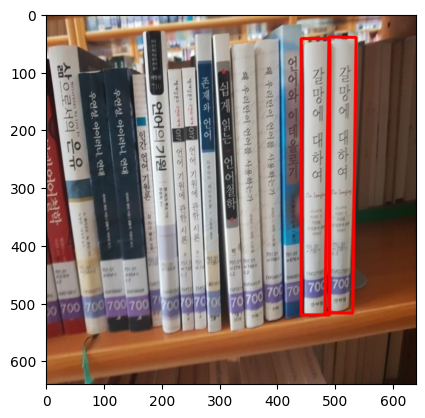

Scene 2:
expected 1 instance(s) of book 17
	Book 17 - 1 instance(s) found:
		Instance 1 {'top_left': (283, 25), 'top_right': (318, 25), 'bottom_left': (283, 503), 'bottom_right': (318, 503), 'area': 16363}


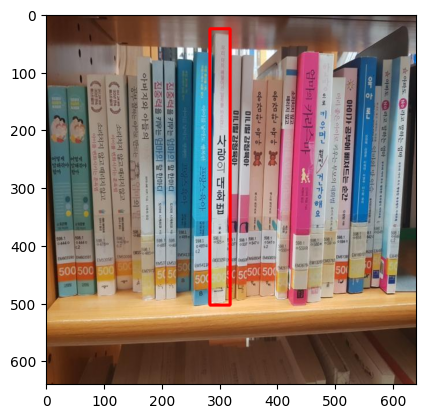

Scene 3:
expected 2 instance(s) of book 16
	Book 16 - 2 instance(s) found:
		Instance 1 {'top_left': (377, 209), 'top_right': (425, 209), 'bottom_left': (377, 542), 'bottom_right': (425, 542), 'area': 16053}
		Instance 2 {'top_left': (425, 211), 'top_right': (474, 209), 'bottom_left': (417, 549), 'bottom_right': (466, 547), 'area': 16491}


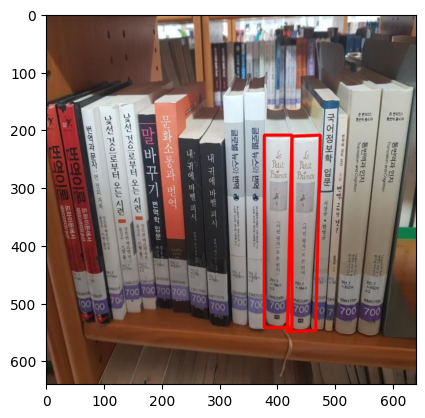

Scene 4:
expected 2 instance(s) of book 14
	Book 14 - 2 instance(s) found:
		Instance 1 {'top_left': (92, 1), 'top_right': (135, 1), 'bottom_left': (92, 616), 'bottom_right': (135, 617), 'area': 26477}
		Instance 2 {'top_left': (55, -3), 'top_right': (98, -3), 'bottom_left': (59, 616), 'bottom_right': (102, 620), 'area': 26577}
expected 2 instance(s) of book 15
	Book 15 - 2 instance(s) found:
		Instance 1 {'top_left': (226, 48), 'top_right': (267, 48), 'bottom_left': (226, 608), 'bottom_right': (267, 608), 'area': 22968}
		Instance 2 {'top_left': (192, 44), 'top_right': (233, 44), 'bottom_left': (196, 609), 'bottom_right': (238, 609), 'area': 23629}


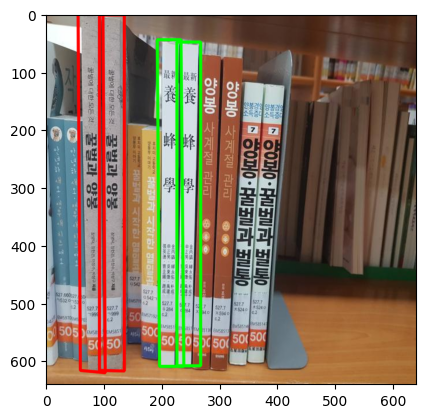

Scene 5:
expected 1 instance(s) of book 13
	Book 13 - 1 instance(s) found:
		Instance 1 {'top_left': (102, 69), 'top_right': (145, 69), 'bottom_left': (102, 572), 'bottom_right': (145, 572), 'area': 21662}


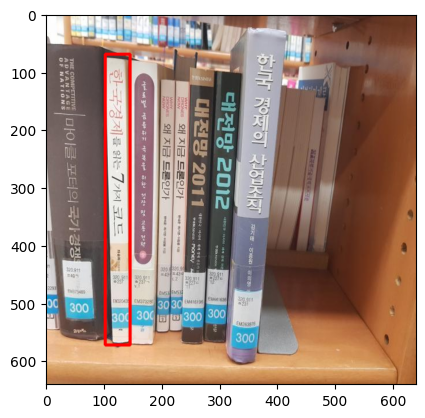

Scene 6:
Scene 7:
expected 2 instance(s) of book 20
	Book 20 - 2 instance(s) found:
		Instance 1 {'top_left': (236, 173), 'top_right': (289, 173), 'bottom_left': (236, 555), 'bottom_right': (289, 555), 'area': 20408}
		Instance 2 {'top_left': (279, 170), 'top_right': (334, 170), 'bottom_left': (275, 561), 'bottom_right': (330, 563), 'area': 21450}


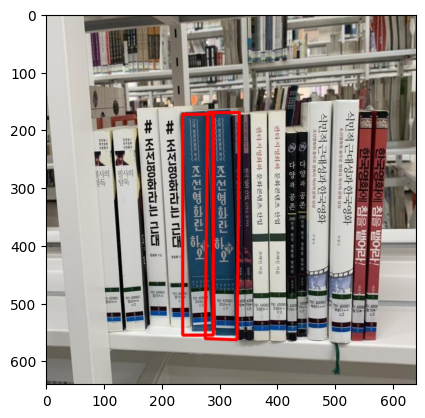

Scene 19:
expected 3 instance(s) of book 6
	Book 6 - 3 instance(s) found:
		Instance 1 {'top_left': (385, 32), 'top_right': (410, 32), 'bottom_left': (385, 579), 'bottom_right': (410, 578), 'area': 14136}
		Instance 2 {'top_left': (439, 26), 'top_right': (465, 27), 'bottom_left': (437, 580), 'bottom_right': (463, 579), 'area': 14532}
		Instance 3 {'top_left': (412, 29), 'top_right': (437, 32), 'bottom_left': (408, 583), 'bottom_right': (434, 580), 'area': 14194}
expected 2 instance(s) of book 7
	Book 7 - 2 instance(s) found:
		Instance 1 {'top_left': (497, 40), 'top_right': (533, 40), 'bottom_left': (497, 587), 'bottom_right': (533, 587), 'area': 19760}
		Instance 2 {'top_left': (458, 44), 'top_right': (494, 42), 'bottom_left': (459, 581), 'bottom_right': (495, 584), 'area': 19419}


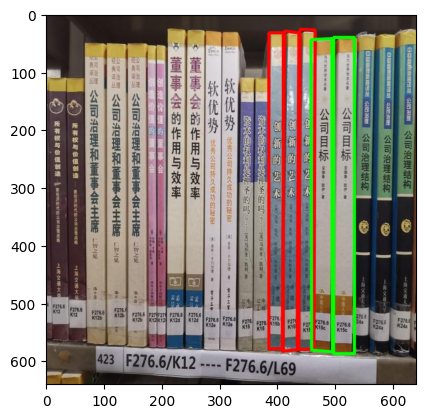

Scene 23:
expected 1 instance(s) of book 5
	Book 5 - 1 instance(s) found:
		Instance 1 {'top_left': (342, 149), 'top_right': (391, 149), 'bottom_left': (342, 572), 'bottom_right': (391, 571), 'area': 20577}


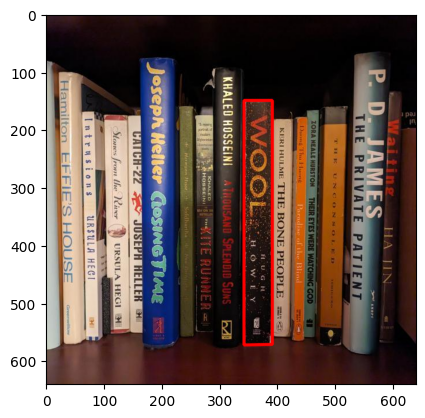

Scene 26:
expected 2 instance(s) of book 0
	Book 0 - 2 instance(s) found:
		Instance 1 {'top_left': (210, 180), 'top_right': (243, 180), 'bottom_left': (210, 567), 'bottom_right': (243, 567), 'area': 12964}
		Instance 2 {'top_left': (169, 181), 'top_right': (203, 181), 'bottom_left': (175, 570), 'bottom_right': (209, 570), 'area': 13279}
expected 1 instance(s) of book 4
	Book 4 - 1 instance(s) found:
		Instance 1 {'top_left': (248, 183), 'top_right': (432, 183), 'bottom_left': (248, 526), 'bottom_right': (432, 526), 'area': 63056}


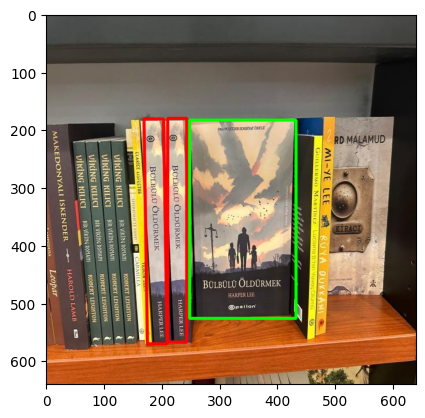

Scene 28:
expected 2 instance(s) of book 1
	Book 1 - 2 instance(s) found:
		Instance 1 {'top_left': (207, 247), 'top_right': (235, 248), 'bottom_left': (206, 554), 'bottom_right': (235, 554), 'area': 8740}
		Instance 2 {'top_left': (237, 247), 'top_right': (265, 244), 'bottom_left': (236, 549), 'bottom_right': (265, 552), 'area': 8612}


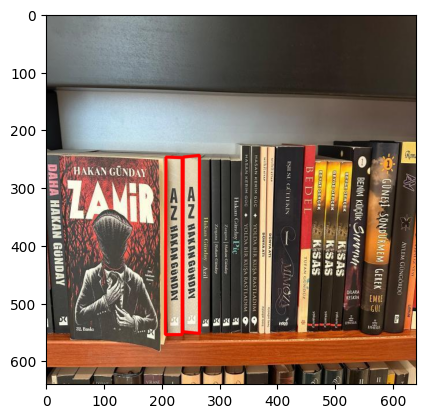

Scene 9:
expected 4 instance(s) of book 19
	Book 19 - 3 instance(s) found:
		Instance 1 {'top_left': (437, 328), 'top_right': (441, 356), 'bottom_left': (137, 338), 'bottom_right': (138, 366), 'area': 8340}
		Instance 2 {'top_left': (438, 303), 'top_right': (437, 331), 'bottom_left': (135, 311), 'bottom_right': (136, 340), 'area': 8591}
		Instance 3 {'top_left': (445, 354), 'top_right': (437, 383), 'bottom_left': (131, 366), 'bottom_right': (149, 393), 'area': 8368}


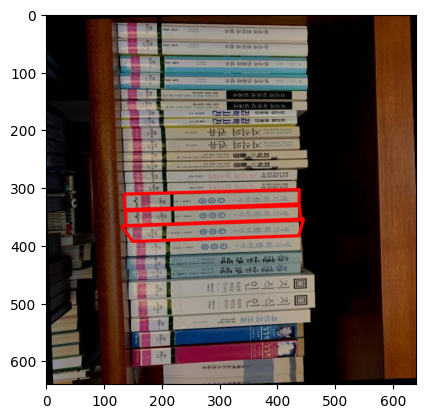

Scene 10:
expected 4 instance(s) of book 19
	Book 19 - 3 instance(s) found:
		Instance 1 {'top_left': (332, 203), 'top_right': (359, 203), 'bottom_left': (332, 503), 'bottom_right': (359, 503), 'area': 8265}
		Instance 2 {'top_left': (307, 204), 'top_right': (335, 201), 'bottom_left': (305, 505), 'bottom_right': (333, 506), 'area': 8561}
		Instance 3 {'top_left': (348, 4), 'top_right': (383, 233), 'bottom_left': (354, 607), 'bottom_right': (380, 451), 'area': 12476}


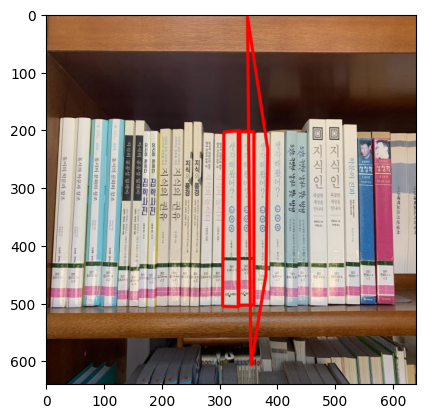

Scene 15:
expected 2 instance(s) of book 11
	Book 11 - 2 instance(s) found:
		Instance 1 {'top_left': (257, 187), 'top_right': (298, 187), 'bottom_left': (251, 533), 'bottom_right': (292, 536), 'area': 14224}
		Instance 2 {'top_left': (217, 178), 'top_right': (258, 189), 'bottom_left': (210, 560), 'bottom_right': (252, 519), 'area': 14698}
expected 3 instance(s) of book 12
	Book 12 - 3 instance(s) found:
		Instance 1 {'top_left': (500, 214), 'top_right': (529, 215), 'bottom_left': (494, 527), 'bottom_right': (523, 527), 'area': 9101}
		Instance 2 {'top_left': (525, 215), 'top_right': (554, 213), 'bottom_left': (519, 515), 'bottom_right': (547, 525), 'area': 8799}
		Instance 3 {'top_left': (472, 211), 'top_right': (504, 214), 'bottom_left': (466, 530), 'bottom_right': (498, 520), 'area': 9951}


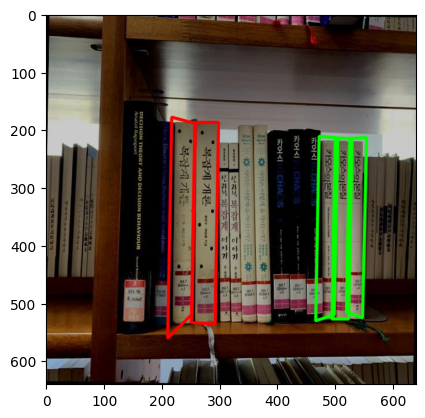

Scene 16:
expected 2 instance(s) of book 11
	Book 11 - 2 instance(s) found:
		Instance 1 {'top_left': (257, 186), 'top_right': (298, 187), 'bottom_left': (251, 533), 'bottom_right': (292, 536), 'area': 14170}
		Instance 2 {'top_left': (221, 192), 'top_right': (266, 158), 'bottom_left': (223, 429), 'bottom_right': (250, 487), 'area': 10283}
expected 3 instance(s) of book 12
	Book 12 - 3 instance(s) found:
		Instance 1 {'top_left': (500, 215), 'top_right': (529, 215), 'bottom_left': (494, 527), 'bottom_right': (523, 527), 'area': 9077}
		Instance 2 {'top_left': (525, 216), 'top_right': (554, 212), 'bottom_left': (519, 512), 'bottom_right': (547, 525), 'area': 8698}
		Instance 3 {'top_left': (472, 212), 'top_right': (504, 214), 'bottom_left': (466, 538), 'bottom_right': (499, 531), 'area': 10422}


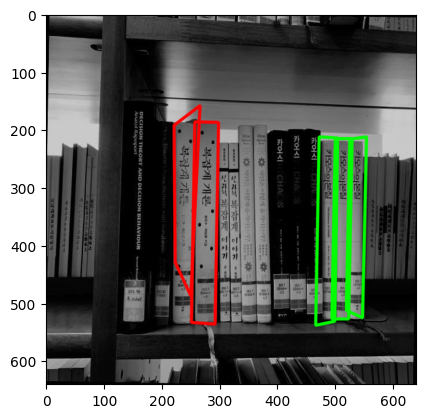

Scene 17:
expected 2 instance(s) of book 11
	Book 11 - 2 instance(s) found:
		Instance 1 {'top_left': (254, 187), 'top_right': (295, 187), 'bottom_left': (254, 535), 'bottom_right': (295, 535), 'area': 14276}
		Instance 2 {'top_left': (211, 180), 'top_right': (247, 183), 'bottom_left': (249, 504), 'bottom_right': (278, 498), 'area': 10616}
expected 3 instance(s) of book 12
	Book 12 - 3 instance(s) found:
		Instance 1 {'top_left': (497, 211), 'top_right': (526, 211), 'bottom_left': (497, 523), 'bottom_right': (526, 523), 'area': 9033}
		Instance 2 {'top_left': (522, 210), 'top_right': (551, 212), 'bottom_left': (521, 525), 'bottom_right': (550, 519), 'area': 8979}
		Instance 3 {'top_left': (471, 211), 'top_right': (502, 207), 'bottom_left': (471, 520), 'bottom_right': (501, 526), 'area': 9597}


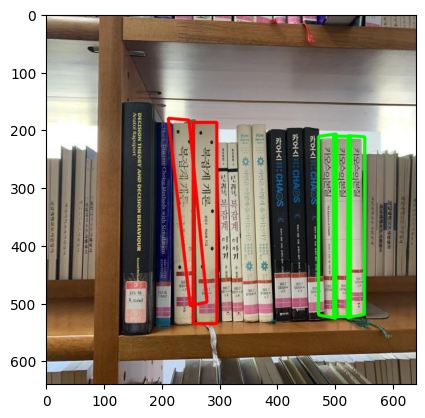

Scene 18:
expected 2 instance(s) of book 8
	Book 8 - 3 instance(s) found:
		Instance 1 {'top_left': (291, 131), 'top_right': (318, 131), 'bottom_left': (291, 587), 'bottom_right': (318, 586), 'area': 12268}
		Instance 2 {'top_left': (314, 133), 'top_right': (341, 133), 'bottom_left': (316, 588), 'bottom_right': (344, 586), 'area': 12342}
		Instance 3 {'top_left': (266, 126), 'top_right': (293, 130), 'bottom_left': (263, 589), 'bottom_right': (290, 582), 'area': 12329}
expected 3 instance(s) of book 10
	Book 10 - 3 instance(s) found:
		Instance 1 {'top_left': (108, 38), 'top_right': (135, 38), 'bottom_left': (108, 584), 'bottom_right': (135, 584), 'area': 14685}
		Instance 2 {'top_left': (138, 41), 'top_right': (165, 41), 'bottom_left': (138, 583), 'bottom_right': (165, 583), 'area': 14523}
		Instance 3 {'top_left': (77, 37), 'top_right': (104, 37), 'bottom_left': (79, 585), 'bottom_right': (106, 584), 'area': 14500}


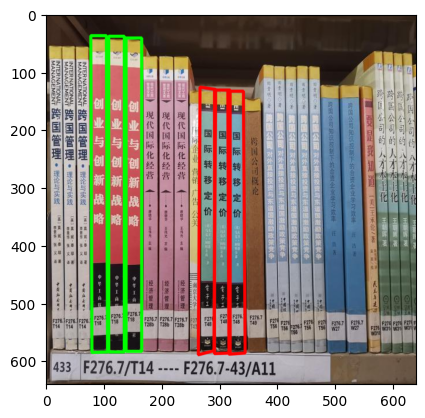

Scene 27:
expected 2 instance(s) of book 2
	Book 2 - 6 instance(s) found:
		Instance 1 {'top_left': (257, 146), 'top_right': (302, 146), 'bottom_left': (257, 563), 'bottom_right': (302, 563), 'area': 18622}
		Instance 2 {'top_left': (308, 109), 'top_right': (367, 114), 'bottom_left': (296, 584), 'bottom_right': (353, 584), 'area': 27489}
		Instance 3 {'top_left': (418, 133), 'top_right': (468, 130), 'bottom_left': (403, 551), 'bottom_right': (445, 554), 'area': 19423}
		Instance 4 {'top_left': (365, 159), 'top_right': (419, 173), 'bottom_left': (345, 580), 'bottom_right': (405, 578), 'area': 23659}
		Instance 5 {'top_left': (532, 249), 'top_right': (563, 244), 'bottom_left': (482, 581), 'bottom_right': (547, 583), 'area': 15985}
		Instance 6 {'top_left': (487, 276), 'top_right': (519, 262), 'bottom_left': (437, 589), 'bottom_right': (506, 614), 'area': 16900}


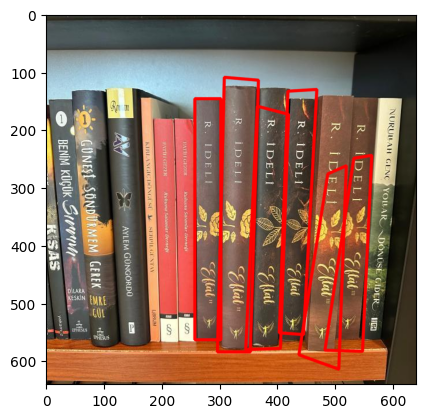

Total errors: 7


In [15]:
# Hyper-parameters
params = {
    'sift_nfeatures': 0, 
    'sift_nOctaveLayers': 6, 
    # 'sift_contrastThreshold': np.float64(0.03898989898989899), 
    # 'sift_edgeThreshold': np.float64(11.666666666666668), 
    'sift_sigma': np.float64(1), 
    'min_match_count': 42, 
    # 'good_matches_threshold': np.float64(0.706060606060606), 
    'mask_scale': 1
}

# Set random seed for reproducibility
cv2.setRNGSeed(1234)

# Five common colors for plotting
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255)]

# Scene paths to analyze
scenes_paths = easy_scene_paths + hard_scene_paths + impossible_scene_paths

# Get models kp, des
kp_des_models = get_keypoints(imgs_model, params)

print(params)
errors = 0

# Scenes loop
for i, s in enumerate(scenes_paths):
    
    # Extract scene index
    scene_index = s.split('_')[1].split('.')[0]
    print(f"Scene {scene_index}:")
    
    # Read scene image
    img_scene = cv2.imread(s)
    img_scene = cv2.cvtColor(img_scene, cv2.COLOR_BGR2RGB)

    # Get ground truth counts for the scene
    gt_counts = ground_truth[f'scene_{scene_index}']

    # Locate books in the scene
    books = locate_books_in_scene_JJJJ(s, kp_des_models, params)

    # Remove books with no instances
    books = {k: v for k, v in books.items() if v}

    # Loop on models found in the scene
    for m_idx, (model_key, instances) in enumerate(books.items()):

        # Extract book index
        book_index = model_key.split('_')[1]

        # Get expected count from ground truth
        expected_count = gt_counts[int(book_index)]

        # Print expected and predicted results
        print(f'expected {expected_count} instance(s) of book {book_index}')
        print(f"\tBook {book_index} - {len(instances)} instance(s) found:")

        errors += abs(expected_count - len(instances))
    
        for k, instance in enumerate(instances):

            # Create and fill the dictionary for printing
            printing_instance = {}
            printing_instance["top_left"] = instance["top_left"]
            printing_instance["top_right"] = instance["top_right"]
            printing_instance["bottom_left"] = instance["bottom_left"]
            printing_instance["bottom_right"] = instance["bottom_right"]
            printing_instance["area"] = instance["area"]

            print(f"\t\tInstance {k+1} {printing_instance}")

            # Draw the bounding box on the scene image
            img_scene = cv2.polylines(img_scene,[np.int32(instance["dst"])], True, colors[m_idx], 3, cv2.LINE_AA)
        
        # Show the scene with all detected books
        plt.imshow(img_scene)
    
    # Plot the scene with the bounding boxes for all books
    plt.show()

print(f'Total errors: {errors}')

   
   